In [93]:
from keras.datasets import mnist
from keras.utils import to_categorical
from keras import layers,models
import numpy as np
import matplotlib.pyplot as plt

In [94]:
(train_x,train_y),(test_x,test_y) = mnist.load_data()

In [95]:
print("train_x.shape : ",train_x.shape)
print("test_x.shape : ",test_x.shape)

train_x.shape :  (60000, 28, 28)
test_x.shape :  (10000, 28, 28)


In [96]:
train_x = train_x.reshape((train_x.shape[0],28*28)).astype('float32') / 255
test_x = test_x.reshape((10000,28*28)).astype('float32') / 255

# train_x = train_x.astype('float32') / 255
# test_x = test_x.astype('float32') / 255

train_y = to_categorical(train_y)
test_y = to_categorical(test_y)

In [97]:
validation_x = train_x[50000:60000]
validation_y = train_y[50000:60000]

train_x = train_x[:50000]
train_y = train_y[:50000]

print("train_x.shape : ",train_x.shape)
print("validation_x.shape : ",validation_x.shape)
print("test_x.shape : ",test_x.shape)

train_x.shape :  (50000, 784)
validation_x.shape :  (10000, 784)
test_x.shape :  (10000, 784)


In [98]:
model = models.Sequential()
model.add(layers.Dense(128, activation='relu', input_shape=(train_x.shape[1],)))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

In [99]:
model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [100]:
history = model.fit(
    train_x,
    train_y,
    epochs=20,
    batch_size=256,
    validation_data=(validation_x, validation_y))

Epoch 1/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8836 - loss: 0.4249 - val_accuracy: 0.9398 - val_loss: 0.2170
Epoch 2/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9463 - loss: 0.1831 - val_accuracy: 0.9574 - val_loss: 0.1484
Epoch 3/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9602 - loss: 0.1313 - val_accuracy: 0.9611 - val_loss: 0.1377
Epoch 4/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9701 - loss: 0.1010 - val_accuracy: 0.9662 - val_loss: 0.1191
Epoch 5/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 980us/step - accuracy: 0.9749 - loss: 0.0815 - val_accuracy: 0.9712 - val_loss: 0.1007
Epoch 6/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 986us/step - accuracy: 0.9802 - loss: 0.0676 - val_accuracy: 0.9629 - val_loss: 0.1279
Epoch 7/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 978us/step - accuracy: 0.9831 - loss: 0.0568 - val_accuracy: 0.9734 - val_loss: 0.0942
Epoch 8/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 975us/step - accuracy: 0.9858 - loss: 0.0484 - val_accu

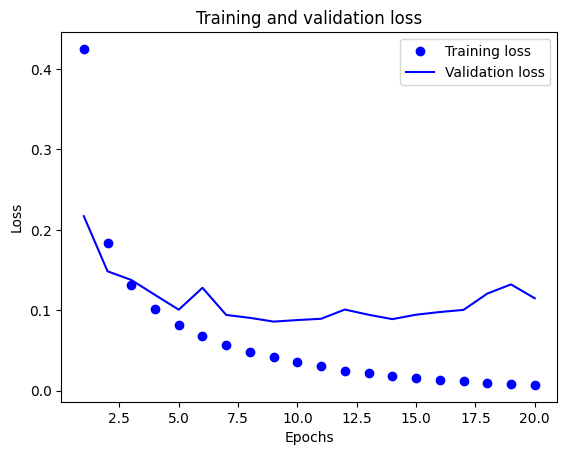

In [101]:
loss = history.history['loss']
val_loss = history.history['val_loss']

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

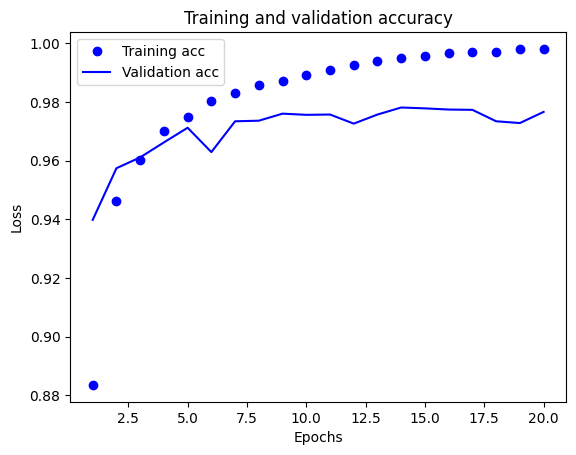

In [102]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.clf()
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()